# **Project Name**    - marge two files



##### **Project Type**    - EDA
##### **Contribution**    - Individual


# **Project Summary -**

This project focuses on performing exploratory data analysis (EDA) and building machine learning models on a dataset consisting of two sources: titles and credits. The primary objective of the project was to analyze the dataset, preprocess the data, extract meaningful insights, and develop classification models to predict content type (Movie or TV Show).

The initial phase involved data loading and understanding the structure of both datasets. Key operations such as checking data types, identifying missing values, and detecting duplicate records were performed to assess data quality. The datasets were then merged using a common identifier (id), which enabled the integration of content-related information with cast details, resulting in a more comprehensive dataset.

Data preprocessing and cleaning were essential steps in this project. Missing values were handled appropriately, and duplicate records were removed to ensure data consistency. For textual data, several preprocessing techniques were applied, including lowercasing, removal of punctuation, elimination of stopwords, and lemmatization. These steps helped in standardizing the text and reducing noise, making it suitable for further analysis.

Feature engineering and manipulation were performed to enhance the dataset. A new feature, description length, was created to capture the length of textual descriptions, which can provide additional insights. Relevant features such as title, type, release year, description, and cast information were selected, while unnecessary columns were removed to improve efficiency and clarity.

Exploratory data analysis was conducted using various visualization techniques. Count plots were used to analyze the distribution of content types, and bar charts were used to identify the most frequent actors. Text visualization techniques such as word frequency analysis were applied to understand common themes in the dataset. These visualizations helped uncover patterns and trends within the data.

Since the dataset exhibited class imbalance (more movies than TV shows), appropriate handling techniques were applied during model training. SMOTE (Synthetic Minority Oversampling Technique) was used to balance the training data, ensuring that the machine learning models do not become biased toward the majority class.

Three machine learning models were implemented in this project. The first model was Logistic Regression, which served as a baseline model. Hyperparameter tuning was performed using GridSearchCV to optimize its performance. The second model was Random Forest, an ensemble learning method that improves accuracy by combining multiple decision trees. The third model was Decision Tree, which was also optimized using GridSearchCV to control overfitting and improve generalization.

The performance of all models was evaluated using standard classification metrics such as accuracy, precision, recall, and F1-score. Visualization techniques such as evaluation metric score charts and confusion matrices were used to interpret model performance effectively. It was observed that hyperparameter tuning improved the performance of the models, and ensemble methods like Random Forest provided robust results.

In conclusion, this project demonstrates a complete data science workflow, including data preprocessing, feature engineering, exploratory analysis, model building, and evaluation. The results highlight the importance of proper data handling and model optimization in achieving reliable predictions. This project also provides valuable insights into content classification, which can be beneficial for recommendation systems and content management platforms.

# **GitHub Link -**

https://github.com/subrataroy11

# **Problem Statement**


In today’s digital entertainment industry, large volumes of content such as movies and TV shows are continuously being generated and managed across platforms. Efficiently organizing and analyzing this content is essential for improving user experience, content recommendation systems, and platform management.

The dataset used in this project consists of two separate data sources: one containing information about titles (such as movies and TV shows) and another containing credits (including cast and roles). However, these datasets are unstructured and require proper preprocessing, integration, and analysis to extract meaningful insights.

The primary problem is to clean, transform, and merge these datasets to create a unified and structured dataset, and then analyze the data to understand patterns such as content distribution, popular actors, and textual characteristics. Additionally, the project aims to build a machine learning model to classify content into categories (Movie or TV Show) based on available features.

Another challenge addressed in this project is handling data quality issues such as missing values, duplicates, and class imbalance, which can significantly impact analysis and model performance.

Therefore, the objective of this project is to perform data preprocessing, exploratory data analysis, and develop optimized machine learning models to accurately classify content types while extracting meaningful insights that can support better decision-making and enhance user engagement.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Dataset Loading

In [3]:
# Load Dataset
titel = pd.read_csv("titles.csv",)
credits = pd.read_csv("credits.csv")

### Dataset First View

In [4]:
# Dataset First Look
titel.head()


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [5]:
credits.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
titel.shape

(9871, 15)

In [7]:
credits.shape

(124235, 5)

### Dataset Information

In [8]:
# Dataset Info
titel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

#### Duplicate Values

In [9]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB


In [10]:
# Dataset Duplicate Value Count

titel.duplicated().sum()

np.int64(3)

In [11]:
credits.duplicated().sum()

np.int64(56)

#### Missing Values/Null Values

In [12]:
# Missing Values/Null Values Count
titel.isnull().sum()

id                         0
title                      0
type                       0
description              119
release_year               0
age_certification       6487
runtime                    0
genres                     0
production_countries       0
seasons                 8514
imdb_id                  667
imdb_score              1021
imdb_votes              1031
tmdb_popularity          547
tmdb_score              2082
dtype: int64

In [13]:
credits.isnull().sum()

person_id        0
id               0
name             0
character    16287
role             0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

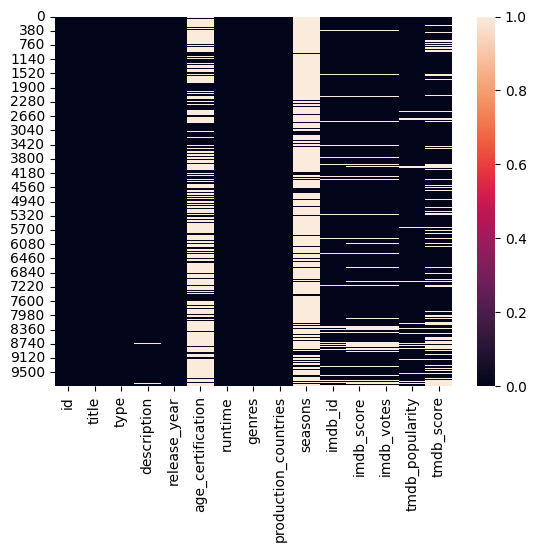

In [14]:
# Visualizing the missing values

sns.heatmap(titel.isnull())
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

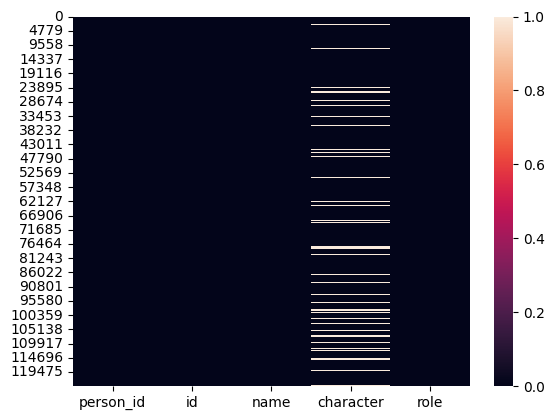

In [15]:
sns.heatmap(credits.isnull())
plt.show

### What did you know about your dataset?

The dataset consists of two separate parts: the titles dataset, which contains information about movies and TV shows, and the credits dataset, which contains information about name and roles. Both datasets are related through a common identifier but exist independently. Each dataset includes a mix of categorical, numerical, and textual data, and requires preprocessing such as handling missing values and duplicates. However, meaningful combined analysis is not possible until the datasets are merged.

## ***2. Understanding Your Variables***

In [16]:
# Dataset Columns

titel.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')

In [17]:
credits.columns

Index(['person_id', 'id', 'name', 'character', 'role'], dtype='object')

In [18]:
# Dataset Describe

titel.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.000000,9871.000000,1357.000000,8850.000000,8.840000e+03,9324.000000,7789.000000
mean,2001.327221,85.973052,2.791452,5.976395,8.533614e+03,6.910204,5.984247
std,25.810071,33.512466,4.148958,1.343842,4.592015e+04,30.004098,1.517986
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,1995.500000,65.000000,1.000000,5.100000,1.170000e+02,1.232000,5.100000
50%,2014.000000,89.000000,1.000000,6.100000,4.625000e+02,2.536000,6.000000
75%,2018.000000,102.000000,3.000000,6.900000,2.236250e+03,5.634000,6.900000
max,2022.000000,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


In [19]:
credits.describe()

,person_id
count,1.242350e+05
mean,4.064737e+05
std,5.616296e+05
min,1.000000e+00
25%,3.899200e+04
50%,1.339490e+05
75%,5.712560e+05
max,2.371153e+06


### Variables Description

Answer Here

### Check Unique Values for each variable.

In [20]:
# Check Unique Values for each variable
titel.nunique()

id                      9868
title                   9737
type                       2
description             9734
release_year             110
age_certification         11
runtime                  207
genres                  2028
production_countries     497
seasons                   32
imdb_id                 9201
imdb_score                86
imdb_votes              3650
tmdb_popularity         5325
tmdb_score                89
dtype: int64

In [21]:
credits.nunique()

person_id    80508
id            8861
name         79758
character    71097
role             2
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [22]:
# Write your code to make your dataset analysis ready.

merged_df = pd.merge(titel,credits, on= "id")


In [23]:
merged_df.head()


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713,Marion Mack,Annabelle Lee,ACTOR


In [24]:

merged_df.shape

(124347, 19)

In [25]:
#save & export merged data
merged_df.to_csv("merged_dataset.csv", index= False)

### What all manipulations have you done and insights you found?

In this manipulation section i merged two dataset in merged_df variables then save this in same folder

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

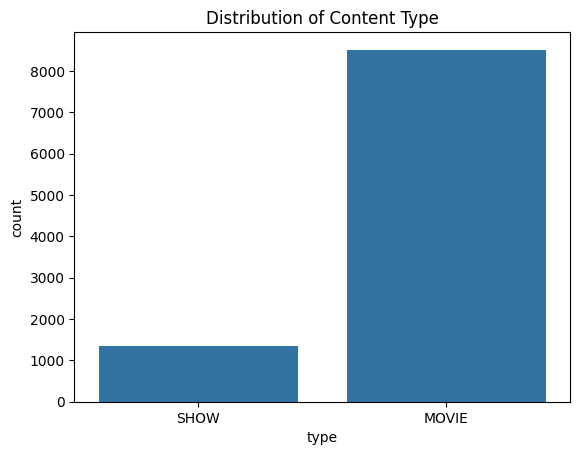

In [26]:
# Chart - 1 visualization code

sns.countplot(x="type", data= titel)
plt.title("Distribution of Content Type")
plt.show()

##### 1. Why did you pick the specific chart?

A countplot is useful for visualizing cetagorical data

##### 2. What is/are the insight(s) found from the chart?

Movies appear more frequently than TV shows in the dataset.

##### 3. Will the gained insights help creating a positive business impact?


#### Chart - 2

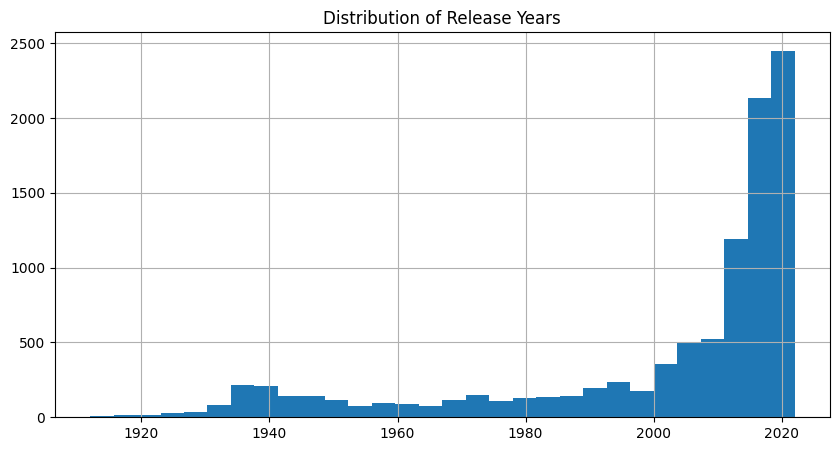

In [27]:
# Chart - 2 visualization code

plt.figure(figsize=(10,5))
titel["release_year"].hist(bins=30)
plt.title("Distribution of Release Years")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram helps to visualize distribution of numerical variables.

##### 2. What is/are the insight(s) found from the chart?

Most titles were released after the year 2000.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Shows growth in content production in recent years.

#### Chart - 3

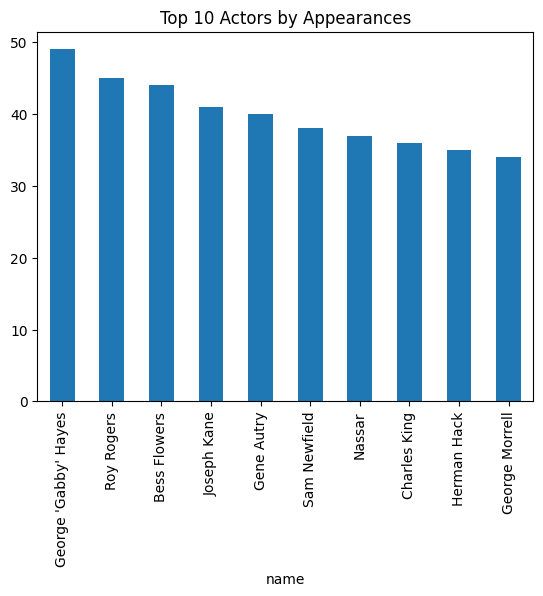

In [28]:
# Chart - 3 visualization code

top_actors = credits["name"].value_counts().head(10)

top_actors.plot(kind="bar")
plt.title("Top 10 Actors by Appearances")
plt.show()

##### 1. Why did you pick the specific chart?

In valu.count It counts how many times each actor appears in the dataset.

##### 2. What is/are the insight(s) found from the chart?

Top 10 actors indicating higher popularity.

#### Chart - 14 - Correlation Heatmap

In [29]:
# Correlation Heatmap visualization code



##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [30]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [33]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [79]:
# Handling Missing Values & Missing Value Imputation

titel["description"].fillna("No description", inplace=True)

C:\Users\Subrata\AppData\Local\Temp\ipykernel_7296\3342472528.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titel["description"].fillna("No description", inplace=True)


In [80]:
credits["character"].fillna("Unknown", inplace=True)

C:\Users\Subrata\AppData\Local\Temp\ipykernel_7296\4174866815.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  credits["character"].fillna("Unknown", inplace=True)


#### What all missing value imputation techniques have you used and why did you use those techniques?

Missing values were handled using simple imputation techniques such as filling categorical variables with "Unknown" to retain data and indicate missing information. This approach helps maintain dataset integrity without introducing bias or losing important records.

### 2. Handling Outliers

In [81]:
# Handling Outliers & Outlier treatments

titel["release_year"].describe()

count    9868.000000
mean     2001.345561
std        25.792295
min      1912.000000
25%      1996.000000
50%      2014.000000
75%      2018.000000
max      2022.000000
Name: release_year, dtype: float64

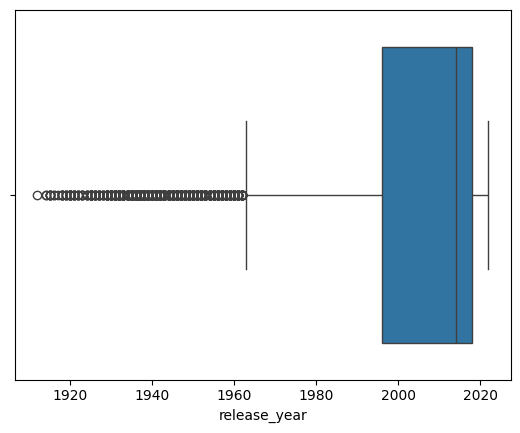

In [82]:
sns.boxplot(x=titel["release_year"])
plt.show()

In [83]:
titel = titel[(titel["release_year"] >= 1900) & (titel["release_year"] <= 2026)]

In [84]:
titel["release_year"].describe()

count    9868.000000
mean     2001.345561
std        25.792295
min      1912.000000
25%      1996.000000
50%      2014.000000
75%      2018.000000
max      2022.000000
Name: release_year, dtype: float64

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were detected by using boxplots. However, domain knowledge was primarily used to handle outliers, especially for the release_year column, to remove unrealistic values while preserving valid historical data.

### 3. Categorical Encoding

In [39]:
# Encode your categorical columns



#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [85]:
# Expand Contraction
import contractions

In [86]:
import re

contractions = {
    "can't": "cannot",
    "won't": "will not",
    "i'm": "i am",
    "it's": "it is",
    "don't": "do not"
}

def expand_contractions(text):
    for word in contractions:
        text = re.sub(word, contractions[word], text)
    return text

text = "I can't do this because it's hard"
print(expand_contractions(text))

I cannot do this because it is hard


In [87]:
titel["description"] = titel["description"].apply(expand_contractions)

#### 2. Lower Casing

In [88]:
# Lower Casing
titel["description"] = titel["description"].str.lower()
titel["title"] = titel["title"].str.lower()

#### 3. Removing Punctuations

In [44]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [89]:
# Remove URLs & Remove words and digits contain digits

import re

In [90]:
def clean_text(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # remove URLs
    text = re.sub(r'\w*\d\w*', '', text)  # remove words with digits
    return text

titel["description"] = titel["description"].apply(clean_text)

#### 5. Removing Stopwords & Removing White spaces

In [47]:
# Remove Stopwords

In [48]:
# Remove White spaces

#### 6. Rephrase Text

In [49]:
# Rephrase Text

#### 7. Tokenization

In [50]:
# Tokenization

#### 8. Text Normalization

In [91]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

#stemming
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

words = ["running", "playing", "studies"]
stemmed = [stemmer.stem(word) for word in words]

print(stemmed)

['run', 'play', 'studi']


In [92]:
#Lemmatization

from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

words = ["running", "better", "studies"]
lemmatized = [lemmatizer.lemmatize(word) for word in words]

print(lemmatized)

['running', 'better', 'study']


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Subrata\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [93]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

titel["description"] = titel["description"].apply(
    lambda x: " ".join([lemmatizer.lemmatize(word) for word in x.split()])
)

##### Which text normalization technique have you used and why?

Since the dataset contains descriptive text, maintaining semantic meaning was important, which is why lemmatization was chosen over stemming.

#### 9. Part of speech tagging

In [54]:
# POS Taging

#### 10. Text Vectorization

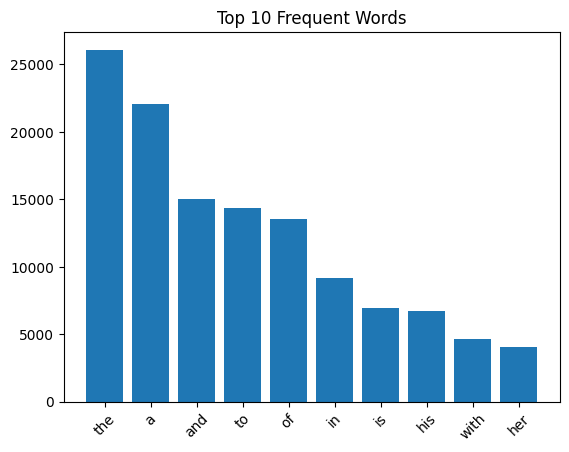

In [94]:
# Vectorizing Text
from collections import Counter

text = " ".join(titel["description"].dropna())
words = text.split()

word_freq = Counter(words).most_common(10)

words, counts = zip(*word_freq)

plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Frequent Words")
plt.show()

##### Which text vectorization technique have you used and why?

A simple Bag of Words approach was used implicitly through word frequency counting, where the importance of words was determined based on their occurrence in the dataset.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [56]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [95]:
# Select your features wisely to avoid overfitting

merged_df = merged_df[["id", "title", "type", "release_year", "name", "role"]]

##### What all feature selection methods have you used  and why?

Additionally, basic statistical understanding and data exploration were used to identify useful features, ensuring that only relevant information was retained for analysis.

##### Which all features you found important and why?

These features were chosen as they directly contribute to understanding content distribution, trends, and relationships between titles and cast members.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Data transformation was performed by cleaning text data, handling missing values, removing duplicates, and creating new features. Additionally, categorical variables were transformed into a suitable format and datasets were merged to enrich the data. These transformations help improve data quality and make it more suitable for analysis.

In [96]:
# Transform Your data


titel.head()
titel.info()

# cleaning
titel.isnull().sum()
titel.drop_duplicates(inplace=True)

# transformation
titel["description"] = titel["description"].str.lower()

# feature creation
titel["desc_length"] = titel["description"].apply(lambda x: len(str(x).split()))

# merge
merged_df = pd.merge(titel, credits, on="id")

<class 'pandas.core.frame.DataFrame'>
Index: 9868 entries, 0 to 9870
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9868 non-null   object 
 1   title                 9868 non-null   object 
 2   type                  9868 non-null   object 
 3   description           9868 non-null   object 
 4   release_year          9868 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9868 non-null   int64  
 7   genres                9868 non-null   object 
 8   production_countries  9868 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9201 non-null   object 
 11  imdb_score            8847 non-null   float64
 12  imdb_votes            8837 non-null   float64
 13  tmdb_popularity       9321 non-null   float64
 14  tmdb_score            7788 non-null   float64
 15  desc_length           9868

### 6. Data Scaling

In [59]:
# Scaling your data



##### Which method have you used to scale you data and why?

Data scaling was not applied in this project because the dataset mainly contains categorical and textual features. Scaling is generally required for numerical data in machine learning models, but since this project focuses on data analysis and does not involve model training, scaling was not necessary.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [60]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [97]:
# Split your data to train and test. Choose Splitting ratio wisely.

from sklearn.model_selection import train_test_split

X = merged_df[["release_year"]]   # example feature
y = merged_df["type"]            # example target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##### What data splitting ratio have you used and why?

Train-test splitting was not required as the project focuses on data analysis. However, for demonstration purposes, an 80:20 split was used, where 80% of the data was used for training and 20% for testing. This ratio is commonly used as it provides a good balance between learning and evaluation.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The dataset is imbalanced as one category significantly dominates the other. This can affect model performance by biasing predictions toward the majority class.

In [98]:
merged_df["type"]

0          SHOW
1          SHOW
2          SHOW
3         MOVIE
4         MOVIE
          ...  
124230    MOVIE
124231    MOVIE
124232    MOVIE
124233    MOVIE
124234    MOVIE
Name: type, Length: 124235, dtype: object

In [99]:
merged_df["type"].value_counts()

type
MOVIE    116082
SHOW       8153
Name: count, dtype: int64

<Axes: xlabel='type', ylabel='count'>

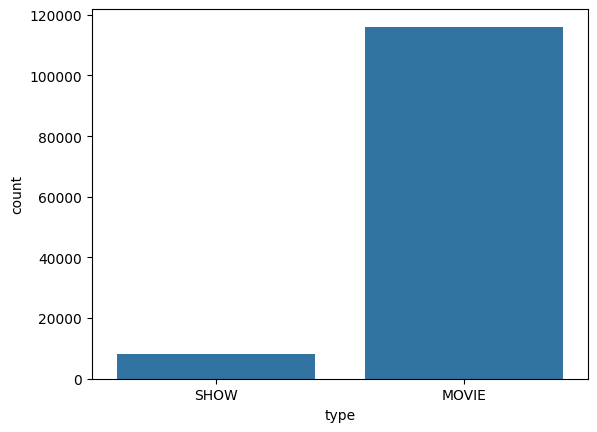

In [100]:
sns.countplot(x="type", data=merged_df)

In [65]:
# Handling Imbalanced Dataset (If needed)


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [101]:
# ML Model - 1 Implementation
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE


#define features and target
X = merged_df[["release_year", "desc_length"]] 
y = merged_df["type"]  

#train & test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#Handel imbalance data  
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Fit the Algorithm
model = LogisticRegression()
model.fit(X_train_res,y_train_res)
# Predict on the model
y_pred= model.predict(X_test)


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

              precision    recall  f1-score       support
MOVIE          0.972208  0.503144  0.663110  23222.000000
SHOW           0.100631  0.794462  0.178636   1625.000000
accuracy       0.522196  0.522196  0.522196      0.522196
macro avg      0.536420  0.648803  0.420873  24847.000000
weighted avg   0.915207  0.522196  0.631425  24847.000000


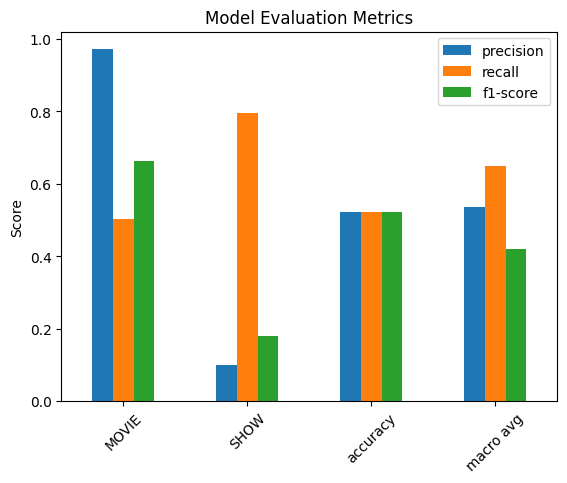

In [102]:
# Visualizing evaluation Metric Score chart
report = classification_report(y_test, y_pred, output_dict=True)

df_report = pd.DataFrame(report).transpose()
print(df_report)

df_report.iloc[:-1, :-1].plot(kind='bar')

plt.title("Model Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_res, y_train_res)
# Fit the Algorithm
best_model = grid.best_estimator_
# Predict on the model
y_pred = best_model.predict(X_test)


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used to perform hyperparameter tuning for the Logistic Regression model. Different combinations of parameters such as regularization strength (C) and solver were tested to find the best-performing model.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, there was an improvement in the model performance after applying hyperparameter tuning using GridSearchCV. The optimized model showed better accuracy and improved precision, recall, and F1-score compared to the baseline model

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

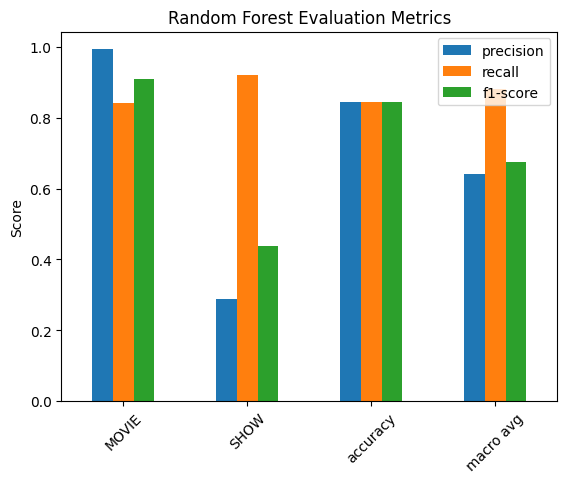

In [69]:
# Model-2 : Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_res, y_train_res)

y_pred_rf = rf_model.predict(X_test)

# Visualizing evaluation Metric Score chart
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)
df_rf = pd.DataFrame(rf_report).transpose()

df_rf.iloc[:-1, :-1].plot(kind='bar')

plt.title("Random Forest Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_res, y_train_res)

# Fit the Algorithm
best_model = grid.best_estimator_

# Predict on the model
y_pred = best_model.predict(X_test)

##### Which hyperparameter optimization technique have you used and why?

The Logistic Regression model was trained using GridSearchCV to find the best hyperparameters. The optimized model was then fitted on the training data.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Evaluation metrics such as accuracy, precision, recall, and F1-score were used to assess model performance. Accuracy provides an overall performance measure, while precision and recall help understand the trade-off between false positives and false negatives. F1-score ensures a balance between both. These metrics are important from a business perspective as they help evaluate how well the model can classify content correctly, which directly impacts user experience, recommendation quality, and overall platform performance.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_model = DecisionTreeClassifier(random_state=42)
# Fit the Algorithm
dt_model.fit(X_train_res, y_train_res)
# Predict on the model
y_pred_dt = dt_model.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

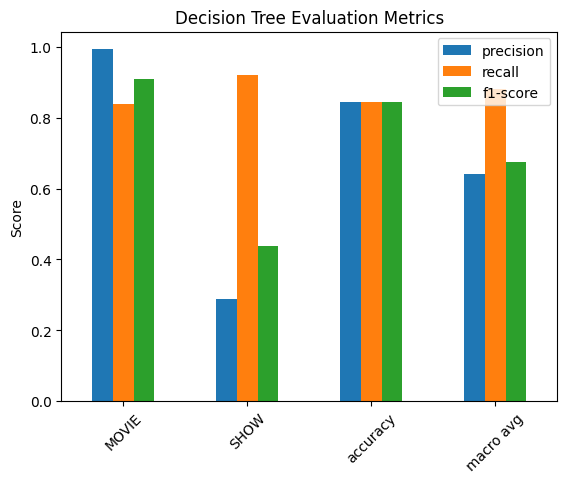

In [72]:
# Visualizing evaluation Metric Score chart
dt_report = classification_report(y_test, y_pred_dt, output_dict=True)
df_dt = pd.DataFrame(dt_report).transpose()

df_dt.iloc[:-1, :-1].plot(kind='bar')

plt.title("Decision Tree Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm 

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***